In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Student

In [51]:
df1 = pd.read_csv('students.csv')
df1.head()

,Student_ID,Name,Age,Gender,Location,Enrolment_Date
0,S001,Student_1,24,Female,Kolkata,24/11/2023
1,S002,Student_2,32,Other,Chennai,27/02/2023
2,S003,Student_3,28,Other,Mumbai,13/01/2023
3,S004,Student_4,25,Female,Bangalore,21/05/2023
4,S005,Student_5,24,Other,Delhi,06/05/2023


In [52]:
df1.isnull().sum()

Student_ID        0
Name              0
Age               0
Gender            0
Location          0
Enrolment_Date    0
dtype: int64

In [53]:
df1.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Length: 100, dtype: bool

In [54]:
df1.describe()

,Age
count,100.000000
mean,25.480000
std,4.835642
min,18.000000
25%,21.000000
50%,25.000000
75%,29.000000
max,34.000000


In [55]:
df1.head()

,Student_ID,Name,Age,Gender,Location,Enrolment_Date
0,S001,Student_1,24,Female,Kolkata,24/11/2023
1,S002,Student_2,32,Other,Chennai,27/02/2023
2,S003,Student_3,28,Other,Mumbai,13/01/2023
3,S004,Student_4,25,Female,Bangalore,21/05/2023
4,S005,Student_5,24,Other,Delhi,06/05/2023


## Course activity

In [56]:
df2 = pd.read_csv('course_activity.csv')
df2

,Student_ID,Course_ID,Date,Time_Spent_Minutes,Completion_Percentage
0,S001,PY202,05/01/2024,90,46.10
1,S001,DM101,28/01/2024,155,88.87
2,S001,UX303,28/01/2024,177,54.93
3,S002,PY202,03/02/2024,45,32.20
4,S002,UX303,15/03/2024,119,90.80
...,...,...,...,...,...
654,S100,PY202,03/03/2024,83,22.63
655,S100,UX303,27/02/2024,168,14.83
656,S100,UX303,02/01/2024,134,22.29
657,S100,WD404,12/03/2024,139,68.78


In [57]:
df2.isnull().sum()

Student_ID               0
Course_ID                0
Date                     0
Time_Spent_Minutes       0
Completion_Percentage    0
dtype: int64

In [58]:
df2.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
654    False
655    False
656    False
657    False
658    False
Length: 659, dtype: bool

In [59]:
df2.describe()

,Time_Spent_Minutes,Completion_Percentage
count,659.000000,659.000000
mean,98.113809,54.778710
std,49.045548,26.289156
min,10.000000,10.150000
25%,58.000000,32.070000
50%,98.000000,53.450000
75%,139.000000,77.560000
max,180.000000,100.000000


In [60]:
df2 = df2.groupby(['Student_ID', 'Course_ID']).agg({
    'Time_Spent_Minutes': 'sum',              # Sum total time spent
    'Completion_Percentage': 'max'            # Take maximum completion percentage
}).reset_index()

In [61]:
df2

,Student_ID,Course_ID,Time_Spent_Minutes,Completion_Percentage
0,S001,DM101,155,88.87
1,S001,PY202,90,46.10
2,S001,UX303,177,54.93
3,S002,DM101,88,71.35
4,S002,PY202,181,32.20
...,...,...,...,...
323,S099,PY202,40,31.47
324,S099,WD404,219,53.80
325,S100,PY202,83,22.63
326,S100,UX303,302,22.29


## Feedback

In [62]:
df3 = pd.read_csv('feedback.csv')
df3.head()

,Student_ID,Course_ID,Rating,Feedback_Text
0,S057,UX303,2,Too fast-paced
1,S063,PY202,2,Loved the examples
2,S022,PY202,4,Could be better
3,S011,PY202,5,Needs improvement
4,S073,WD404,4,Could be better


In [63]:
df3.isnull().sum()

Student_ID       0
Course_ID        0
Rating           0
Feedback_Text    0
dtype: int64

In [64]:
df2.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
323    False
324    False
325    False
326    False
327    False
Length: 328, dtype: bool

In [65]:
df2.describe()

,Time_Spent_Minutes,Completion_Percentage
count,328.000000,328.00000
mean,197.125000,66.24753
std,128.185119,25.07651
min,11.000000,10.85000
25%,99.000000,48.15750
50%,167.000000,70.97000
75%,270.250000,87.76000
max,688.000000,100.00000


## Merging of 3 csv files

In [66]:
df = df1.merge(df2, on = 'Student_ID', how = 'outer')
df

,Student_ID,Name,Age,Gender,Location,Enrolment_Date,Course_ID,Time_Spent_Minutes,Completion_Percentage
0,S001,Student_1,24,Female,Kolkata,24/11/2023,DM101,155,88.87
1,S001,Student_1,24,Female,Kolkata,24/11/2023,PY202,90,46.10
2,S001,Student_1,24,Female,Kolkata,24/11/2023,UX303,177,54.93
3,S002,Student_2,32,Other,Chennai,27/02/2023,DM101,88,71.35
4,S002,Student_2,32,Other,Chennai,27/02/2023,PY202,181,32.20
...,...,...,...,...,...,...,...,...,...
323,S099,Student_99,18,Male,Kolkata,17/12/2023,PY202,40,31.47
324,S099,Student_99,18,Male,Kolkata,17/12/2023,WD404,219,53.80
325,S100,Student_100,22,Other,Bangalore,16/06/2023,PY202,83,22.63
326,S100,Student_100,22,Other,Bangalore,16/06/2023,UX303,302,22.29


In [67]:

df_merged = df.merge(df3, on = ['Student_ID','Course_ID'] , how = 'outer')
df_merged

,Student_ID,Name,Age,Gender,Location,Enrolment_Date,Course_ID,Time_Spent_Minutes,Completion_Percentage,Rating,Feedback_Text
0,S001,Student_1,24.0,Female,Kolkata,24/11/2023,DM101,155.0,88.87,NaN,NaN
1,S001,Student_1,24.0,Female,Kolkata,24/11/2023,PY202,90.0,46.10,NaN,NaN
2,S001,Student_1,24.0,Female,Kolkata,24/11/2023,UX303,177.0,54.93,NaN,NaN
3,S002,Student_2,32.0,Other,Chennai,27/02/2023,DM101,88.0,71.35,NaN,NaN
4,S002,Student_2,32.0,Other,Chennai,27/02/2023,PY202,181.0,32.20,3.0,Well structured
...,...,...,...,...,...,...,...,...,...,...,...
340,S099,Student_99,18.0,Male,Kolkata,17/12/2023,WD404,219.0,53.80,5.0,Needs improvement
341,S100,NaN,NaN,NaN,NaN,NaN,DM101,NaN,NaN,4.0,Too fast-paced
342,S100,Student_100,22.0,Other,Bangalore,16/06/2023,PY202,83.0,22.63,NaN,NaN
343,S100,Student_100,22.0,Other,Bangalore,16/06/2023,UX303,302.0,22.29,NaN,NaN


In [68]:
df_merged.isnull().sum()

Student_ID                 0
Name                      17
Age                       17
Gender                    17
Location                  17
Enrolment_Date            17
Course_ID                  0
Time_Spent_Minutes        17
Completion_Percentage     17
Rating                   265
Feedback_Text            265
dtype: int64

In [69]:
df_merged.dropna(subset=['Name','Age'],inplace = True)

In [70]:
df_merged.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
339    False
340    False
342    False
343    False
344    False
Length: 328, dtype: bool

df_merged.drop_duplicates()

## Exporting cleaned Merged Dataset

In [71]:
df_merged.to_csv('merged_file.csv')

## EDA

### 1️⃣ Overall average completion rate across courses


Overall average completion rate: 66.25%


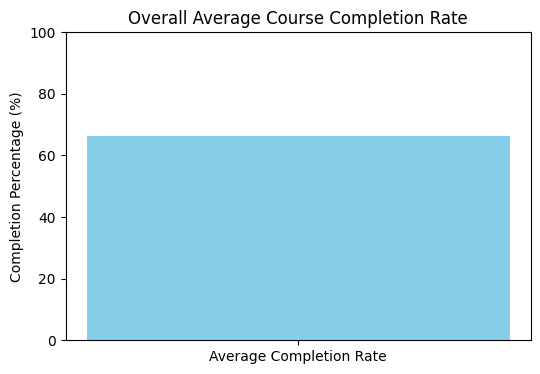

In [72]:
overall_avg_completion = df_merged['Completion_Percentage'].mean()
print("Overall average completion rate: {:.2f}%".format(overall_avg_completion))

plt.figure(figsize=(6, 4))
plt.bar(['Average Completion Rate'], [overall_avg_completion], color='skyblue')
plt.ylabel('Completion Percentage (%)')
plt.ylim(0, 100)
plt.title('Overall Average Course Completion Rate')
plt.show()


### 2️⃣ Courses with highest and lowest average engagement time


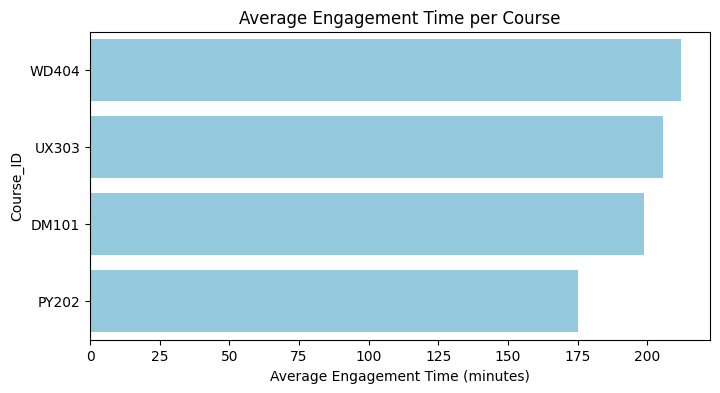

In [76]:
engagement_per_course = df_merged.groupby('Course_ID')['Time_Spent_Minutes'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=engagement_per_course.values, y=engagement_per_course.index, color='skyblue')
plt.xlabel('Average Engagement Time (minutes)')
plt.title('Average Engagement Time per Course')
plt.show()


### 3️⃣ Engagement by Age Group

In [80]:
bins = [0, 18, 25, 35, 50, 100]
labels = ['<18', '18-25', '26-35', '36-50', '50+']
df_merged['Age_Group'] = pd.cut(df_merged['Age'], bins=bins, labels=labels)


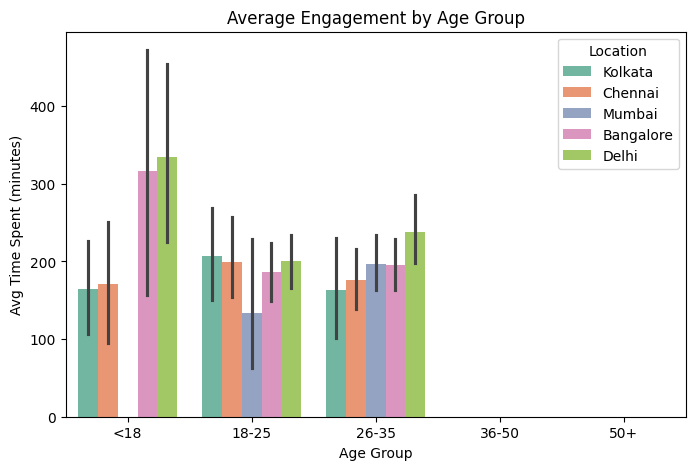

In [87]:
age_group_engagement = df_merged.groupby('Age_Group', observed=False)['Time_Spent_Minutes'].mean().reset_index()

colors = sns.color_palette('Set2', len(age_group_engagement))

plt.figure(figsize=(8, 5))
sns.barplot(data=df_merged, x='Age_Group', y='Time_Spent_Minutes', hue='Location', palette='Set2')
plt.title('Average Engagement by Age Group')
plt.ylabel('Avg Time Spent (minutes)')
plt.xlabel('Age Group')
plt.show()


###  4️⃣ Engagement by Location (Top 10)


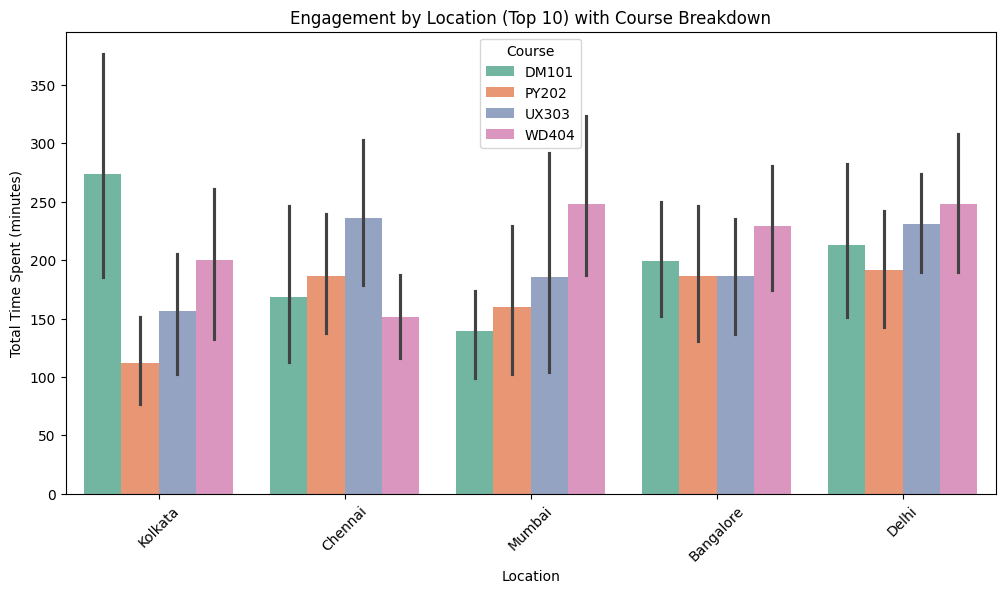

In [94]:
# Top 10 locations by total engagement
top_locations = df_merged.groupby('Location')['Time_Spent_Minutes'].sum().sort_values(ascending=False).head(10).index

# Filter data for only those locations
top_location_data = df_merged[df_merged['Location'].isin(top_locations)]

# Plot with hue = Course_Name
plt.figure(figsize=(12, 6))
sns.barplot(data=top_location_data, x='Location', y='Time_Spent_Minutes', hue='Course_ID', palette='Set2')
plt.title('Engagement by Location (Top 10) with Course Breakdown')
plt.ylabel('Total Time Spent (minutes)')
plt.xlabel('Location')
plt.legend(title='Course')
plt.xticks(rotation=45)
plt.show()


### 5️⃣ Average Feedback Rating per Course


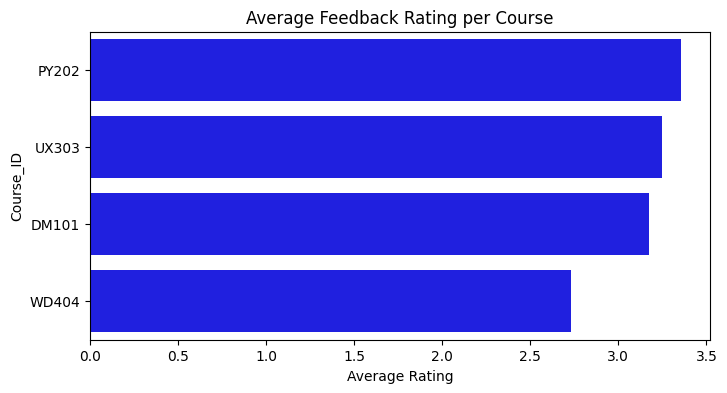

In [98]:
rating_per_course = df_merged.groupby('Course_ID')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=rating_per_course.values, y=rating_per_course.index, color='Blue')
plt.xlabel('Average Rating')
plt.title('Average Feedback Rating per Course')
plt.show()


### 6️⃣ Correlation: Completion % vs Rating (Scatterplot + Correlation Value)


Correlation between Completion % and Rating: -0.14


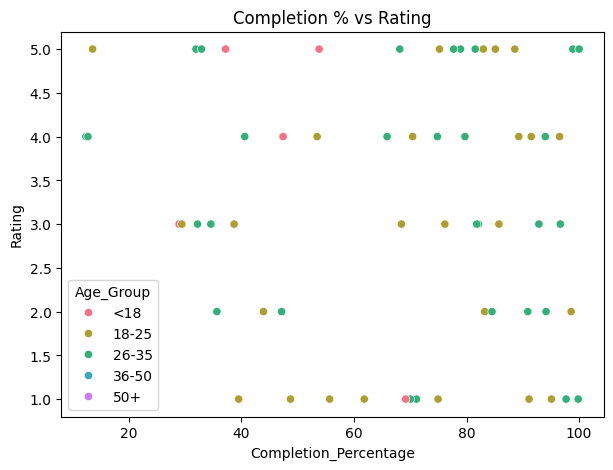

In [100]:
 corr_value = df_merged[['Completion_Percentage', 'Rating']].corr().iloc[0, 1]
print("Correlation between Completion % and Rating: {:.2f}".format(corr_value))

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_merged, x='Completion_Percentage', y='Rating', hue='Age_Group', palette='husl')
plt.title('Completion % vs Rating')
plt.show()


###  7️⃣ Top 3 Students by Engagement and Satisfaction


In [105]:
student_engagement = df_merged.groupby('Student_ID').agg({
    'Time_Spent_Minutes': 'sum',
}).reset_index()

# Top 3 students sorted by both metrics
top_students = student_engagement.sort_values(
    by=['Time_Spent_Minutes'], ascending=False
).head(3)

print(top_students)

   Student_ID  Time_Spent_Minutes
41       S042              1329.0
23       S024              1238.0
65       S066              1158.0
